# Churn Prediction — Banking Transaction Data
**CRISP-DM Framework**

**Goal:** Identify customers likely to churn (stop transacting) so the bank can run targeted re-engagement campaigns.

**Churn definition used here:** A customer is labeled **churned** if their last transaction occurred more than `CHURN_DAYS` days before the snapshot date. Adjust `CHURN_DAYS` to fit business policy.

## 0. Setup & Config

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ── Config ────────────────────────────────────────────────────────────────────
CHURN_DAYS   = 30    # customers with recency > this are labeled churned
RANDOM_STATE = 42
TEST_SIZE    = 0.2

# Data URLs (same as bagian1 notebook)
URL_INDIA   = 'https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/bank_customer_transactions.csv'
URL_FOREIGN = 'https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/foreign_customer_dataset.csv'

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Merging

In [15]:
df_india   = pd.read_csv(URL_INDIA)
df_foreign = pd.read_csv(URL_FOREIGN)

# Drop helper columns from foreign dataset
df_foreign = df_foreign.drop(columns=[c for c in ['Unnamed: 0', 'Age'] if c in df_foreign.columns])

# Tag origin (optional — useful for analysis later)
df_india['source']   = 'india'
df_foreign['source'] = 'foreign'

df = pd.concat([df_india, df_foreign], ignore_index=True)
print(f'Combined shape: {df.shape}')
df.head(3)

Combined shape: (1052151, 10)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),source
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0,india
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0,india
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0,india


## 2. Preprocessing & Feature Engineering

In [16]:
# ── 2.1 Parse dates ───────────────────────────────────────────────────────────
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB']     = pd.to_datetime(df['CustomerDOB'],     dayfirst=True, errors='coerce')

snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date (T+1 from latest tx): {snapshot_date.date()}')

# ── 2.2 Fix century-ambiguity on DOB ──────────────────────────────────────────
future_mask = df['CustomerDOB'] > snapshot_date
df.loc[future_mask, 'CustomerDOB'] -= pd.DateOffset(years=100)
print(f'DOB century corrections: {future_mask.sum():,}')

# ── 2.3 Temporal features ─────────────────────────────────────────────────────
df['Age'] = ((snapshot_date - df['CustomerDOB']).dt.days / 365.25).round(1)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour'] = pd.to_numeric(df['TransactionTime'].str[:2], errors='coerce')
df['is_weekend']      = df['TransactionDate'].dt.dayofweek.isin([5, 6]).astype(int)

print(f'Age null count after cleaning: {df["Age"].isna().sum():,}')

Snapshot date (T+1 from latest tx): 2016-10-22
DOB century corrections: 117,578
Age null count after cleaning: 62,501


In [17]:
# ── 2.4 Build per-customer feature table ──────────────────────────────────────
customer_features = df.groupby('CustomerID').agg(

    # RFM core
    Recency          = ('TransactionDate',        lambda x: (snapshot_date - x.max()).days),
    Frequency        = ('TransactionID',          'nunique'),
    Monetary         = ('TransactionAmount (INR)', 'sum'),

    # Transaction stats
    AvgTransaction   = ('TransactionAmount (INR)', 'mean'),
    MaxTransaction   = ('TransactionAmount (INR)', 'max'),
    StdTransaction   = ('TransactionAmount (INR)', 'std'),

    # Account
    AccountBalance   = ('CustAccountBalance',     'last'),

    # Behavioral
    AvgHour          = ('TransactionHour',         'mean'),
    WeekendRate      = ('is_weekend',               'mean'),
    ActiveMonths     = ('TransactionDate',          lambda x: x.dt.month.nunique()),

    # Demographics
    Age              = ('Age',                     'first'),
    Gender           = ('CustGender',              'first'),
    source           = ('source',                  'first'),

).reset_index()

customer_features['StdTransaction'] = customer_features['StdTransaction'].fillna(0)

print(f'Customer-level table shape: {customer_features.shape}')
customer_features.head(3)

Customer-level table shape: (884265, 14)


,CustomerID,Recency,Frequency,Monetary,AvgTransaction,MaxTransaction,StdTransaction,AccountBalance,AvgHour,WeekendRate,ActiveMonths,Age,Gender,source
0,C1010011,26,2,5106.0,2553.0,4750.0,3107.027197,120180.54,6.5,0.0,2,24.2,F,india
1,C1010012,69,1,1499.0,1499.0,1499.0,0.000000,24204.49,20.0,1.0,1,22.2,M,india
2,C1010014,76,2,1455.0,727.5,1205.0,675.286976,161848.76,18.5,0.5,1,24.4,F,india


## 3. Define Churn Label

Churn threshold : 30 days
Churned         : 840,460  (95.0%)
Active          : 43,805  (5.0%)


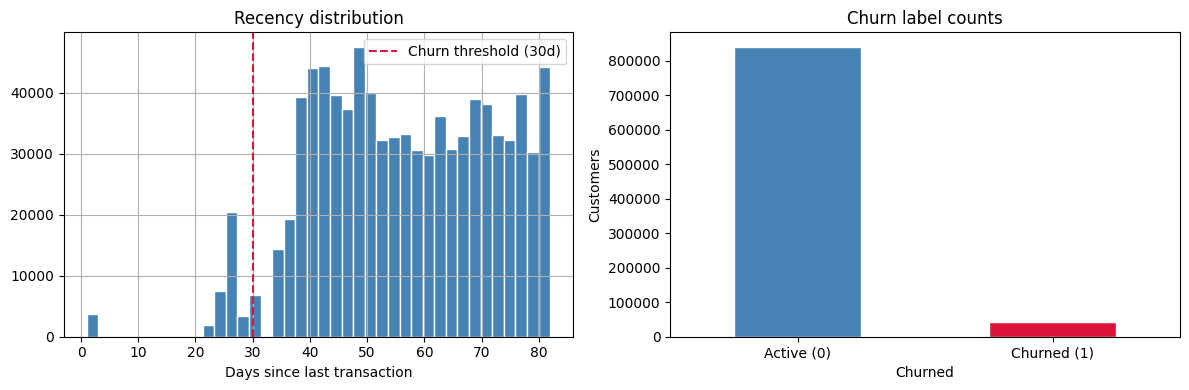

In [18]:
customer_features['Churned'] = (customer_features['Recency'] > CHURN_DAYS).astype(int)

churn_rate = customer_features['Churned'].mean() * 100
print(f'Churn threshold : {CHURN_DAYS} days')
print(f'Churned         : {customer_features["Churned"].sum():,}  ({churn_rate:.1f}%)')
print(f'Active          : {(customer_features["Churned"]==0).sum():,}  ({100-churn_rate:.1f}%)')

# Visualise churn vs recency distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

customer_features['Recency'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(CHURN_DAYS, color='crimson', linestyle='--', label=f'Churn threshold ({CHURN_DAYS}d)')
axes[0].set_title('Recency distribution')
axes[0].set_xlabel('Days since last transaction')
axes[0].legend()

customer_features['Churned'].value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'crimson'], edgecolor='white'
)
axes[1].set_title('Churn label counts')
axes[1].set_xticklabels(['Active (0)', 'Churned (1)'], rotation=0)
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('churn_label_overview.png', dpi=150)
plt.show()

## 4. Feature Selection & Encoding

In [19]:
NUMERIC_FEATURES = [
    'Frequency', 'Monetary', 'AvgTransaction', 'MaxTransaction',
    'StdTransaction', 'AccountBalance', 'AvgHour', 'WeekendRate',
    'ActiveMonths', 'Age'
]

# NOTE: Recency is excluded because it directly determines the label —
# including it would cause data leakage (100% importance, useless in production).

# Encode Gender
le = LabelEncoder()
customer_features['Gender_enc'] = le.fit_transform(
    customer_features['Gender'].fillna('Unknown')
)
customer_features['source_enc'] = le.fit_transform(customer_features['source'])

FEATURES = NUMERIC_FEATURES + ['Gender_enc', 'source_enc']

X = customer_features[FEATURES].copy()
y = customer_features['Churned']

# Fill remaining nulls with median
X = X.fillna(X.median())

print(f'Feature matrix: {X.shape}')
print(f'Class balance — Active: {(y==0).sum():,} | Churned: {(y==1).sum():,}')

Feature matrix: (884265, 12)
Class balance — Active: 43,805 | Churned: 840,460


## 5. Train / Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y          # preserve class ratio
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')

Train: 707,412 rows | Test: 176,853 rows


## 6. Model Training & Comparison

In [21]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    ),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    test_auc    = roc_auc_score(y_test, y_pred_prob)

    results[name] = {
        'model':      model,
        'cv_auc':     cv_scores.mean(),
        'cv_std':     cv_scores.std(),
        'test_auc':   test_auc,
        'y_pred':     y_pred,
        'y_pred_prob': y_pred_prob,
    }
    print(f'{name:<25} CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  |  Test AUC: {test_auc:.4f}')

Logistic Regression       CV AUC: 0.6417 ± 0.0026  |  Test AUC: 0.6457
Random Forest             CV AUC: 0.6911 ± 0.0021  |  Test AUC: 0.7010
Gradient Boosting         CV AUC: 0.6945 ± 0.0027  |  Test AUC: 0.7021


## 7. Evaluation — Best Model

In [22]:
# Pick best model by test AUC
best_name  = max(results, key=lambda n: results[n]['test_auc'])
best       = results[best_name]
print(f'Best model: {best_name}  (AUC = {best["test_auc"]:.4f})')
print()
print(classification_report(y_test, best['y_pred'], target_names=['Active', 'Churned']))

Best model: Gradient Boosting  (AUC = 0.7021)

              precision    recall  f1-score   support

      Active       0.92      0.00      0.01      8761
     Churned       0.95      1.00      0.97    168092

    accuracy                           0.95    176853
   macro avg       0.94      0.50      0.49    176853
weighted avg       0.95      0.95      0.93    176853



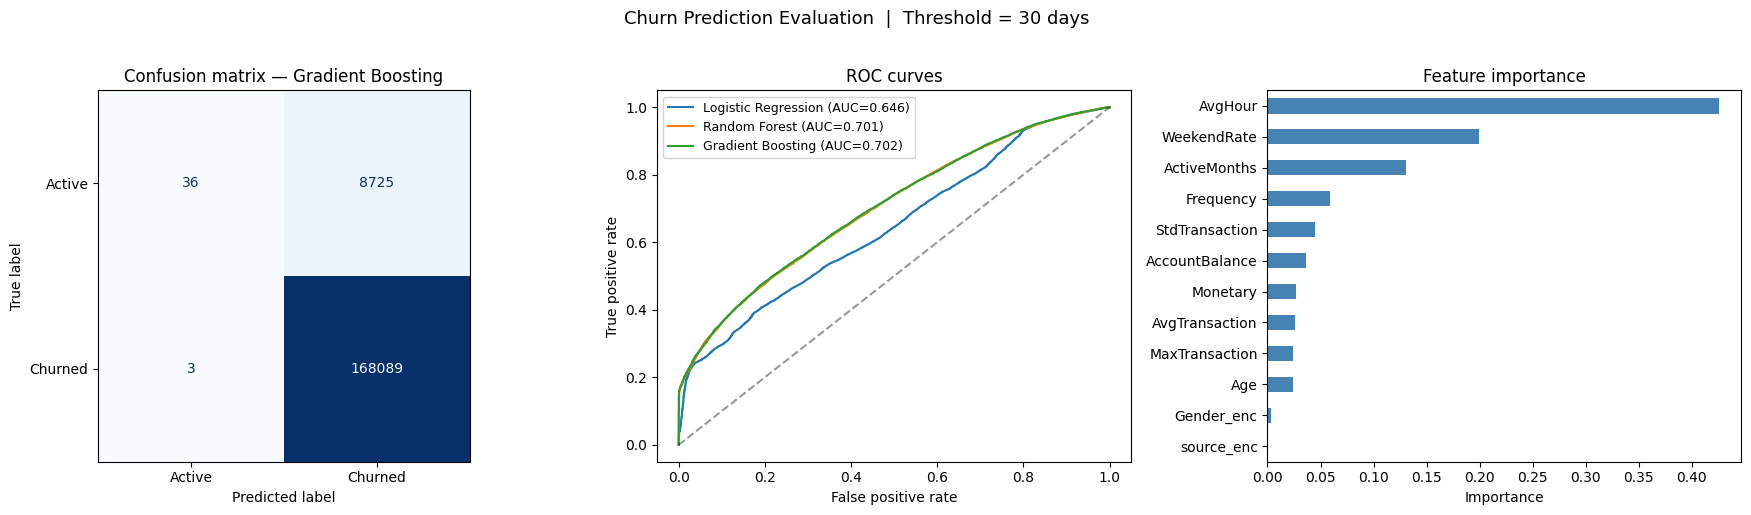

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best['y_pred']),
    display_labels=['Active', 'Churned']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion matrix — {best_name}')

# ── ROC curves (all models) ───────────────────────────────────────────────────
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={res["test_auc"]:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curves')
axes[1].legend(fontsize=9)

# ── Feature importance (Random Forest or GBM) ────────────────────────────────
imp_model = results.get('Random Forest') or results.get('Gradient Boosting')
if imp_model:
    clf = imp_model['model']
    clf = clf.named_steps['clf'] if hasattr(clf, 'named_steps') else clf
    importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[2], color='steelblue')
    axes[2].set_title('Feature importance')
    axes[2].set_xlabel('Importance')

plt.suptitle(f'Churn Prediction Evaluation  |  Threshold = {CHURN_DAYS} days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('churn_evaluation.png', dpi=150)
plt.show()

## 8. Churn Probability Scoring

In [24]:
# Score ALL customers, not just the test set
X_all = customer_features[FEATURES].fillna(customer_features[FEATURES].median())

best_model = best['model']
customer_features['churn_prob']  = best_model.predict_proba(X_all)[:, 1]
customer_features['churn_pred']  = best_model.predict(X_all)

# Risk tiers
def risk_tier(p):
    if p >= 0.75: return 'High risk'
    if p >= 0.50: return 'Medium risk'
    return 'Low risk'

customer_features['risk_tier'] = customer_features['churn_prob'].apply(risk_tier)

print('Risk tier distribution:')
print(customer_features['risk_tier'].value_counts().to_string())

customer_features[['CustomerID', 'Recency', 'Frequency', 'Monetary',
                    'churn_prob', 'risk_tier']].sort_values(
    'churn_prob', ascending=False
).head(10)

Risk tier distribution:
risk_tier
High risk      883996
Medium risk       145
Low risk          124


,CustomerID,Recency,Frequency,Monetary,churn_prob,risk_tier
775987,C8114469,63,1,3540.0,0.998244,High risk
739211,C7738861,56,1,246.0,0.998159,High risk
881330,C9038874,56,1,239.0,0.998159,High risk
154002,C2414467,63,1,1911.0,0.998148,High risk
159001,C2432683,56,1,100000.0,0.998139,High risk
115346,C2032863,55,1,100000.0,0.998106,High risk
559347,C6121775,42,1,62899.0,0.998072,High risk
737554,C7732836,55,1,100000.0,0.998066,High risk
771976,C8039279,76,1,183042.0,0.998026,High risk
612437,C6616313,42,1,2805.4,0.998021,High risk


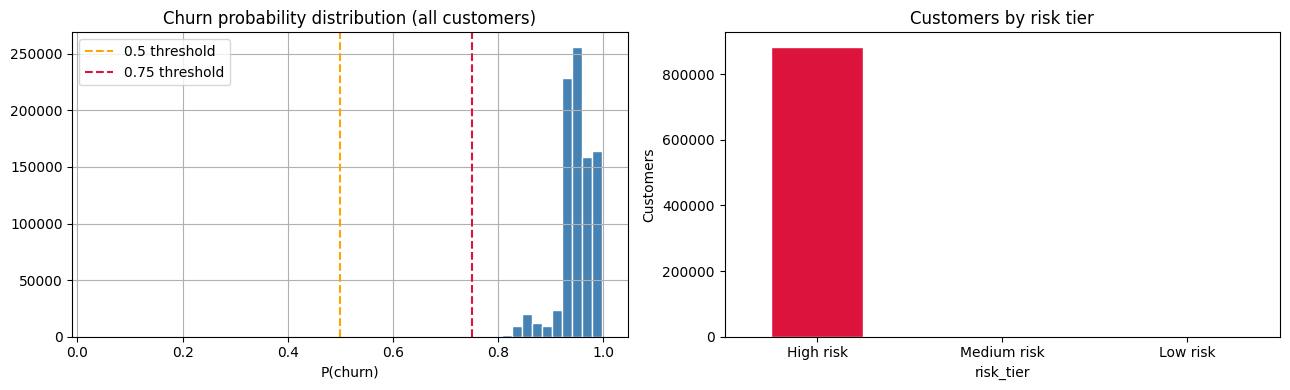

In [25]:
# Distribution of churn probability scores
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

customer_features['churn_prob'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.5,  color='orange', linestyle='--', label='0.5 threshold')
axes[0].axvline(0.75, color='crimson', linestyle='--', label='0.75 threshold')
axes[0].set_title('Churn probability distribution (all customers)')
axes[0].set_xlabel('P(churn)')
axes[0].legend()

customer_features['risk_tier'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['crimson', 'steelblue', 'orange'],
    edgecolor='white'
)
axes[1].set_title('Customers by risk tier')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('churn_risk_tiers.png', dpi=150)
plt.show()

## 9. Export — Actionable Churn List

In [26]:
# Export high-risk, currently active customers (not yet labeled churned)
# These are the prime re-engagement targets.
high_risk_active = customer_features[
    (customer_features['risk_tier'] == 'High risk') &
    (customer_features['Churned']   == 0)
].sort_values('churn_prob', ascending=False)

print(f'High-risk active customers to target: {len(high_risk_active):,}')

output_cols = [
    'CustomerID', 'Recency', 'Frequency', 'Monetary',
    'AccountBalance', 'Age', 'Gender', 'source',
    'churn_prob', 'risk_tier'
]
high_risk_active[output_cols].to_csv('churn_target_list.csv', index=False)
print('Saved → churn_target_list.csv')

high_risk_active[output_cols].head(10)

High-risk active customers to target: 43,581
Saved → churn_target_list.csv


,CustomerID,Recency,Frequency,Monetary,AccountBalance,Age,Gender,source,churn_prob,risk_tier
847550,C8735171,27,1,1200.00,79.48,25.8,M,india,0.997613,High risk
792506,C8235125,27,1,1200.00,79.48,25.8,M,india,0.997613,High risk
572520,C6230340,27,1,3515.75,8448.41,33.5,M,india,0.997397,High risk
765958,C8017287,27,1,620.00,49333.33,25.1,M,india,0.997391,High risk
65825,C1612070,27,1,120.00,15363.19,24.1,F,india,0.997387,High risk
831927,C8618858,27,1,6856.91,12024.26,34.3,M,india,0.997289,High risk
739719,C7740749,27,1,3060.00,176555.43,33.4,M,india,0.997197,High risk
799262,C8319384,27,1,145.00,2556.23,26.2,F,india,0.997144,High risk
580359,C6318873,27,1,6856.91,12024.26,34.3,M,india,0.997094,High risk
689907,C7318879,27,1,6856.91,12024.26,34.3,M,india,0.997094,High risk


## 10. Summary

| Step | Detail |
|------|--------|
| **Churn definition** | Recency > `CHURN_DAYS` days |
| **Features used** | Frequency, Monetary, AvgTx, MaxTx, StdTx, AccountBalance, AvgHour, WeekendRate, ActiveMonths, Age, Gender, Source |
| **Leakage guard** | Recency explicitly excluded from features |
| **Models compared** | Logistic Regression, Random Forest, Gradient Boosting |
| **Selection metric** | ROC-AUC (with 5-fold stratified CV) |
| **Class imbalance** | Handled via `class_weight='balanced'` |
| **Output** | Per-customer churn probability + risk tier + CSV export |

### Next Steps
- **Tune `CHURN_DAYS`** — try 30, 45, 60, 90 days based on business churn definition
- **Add XGBoost / LightGBM** for potentially higher AUC
- **Threshold tuning** — shift decision threshold to optimise recall (catch more churners) vs precision (reduce wasted outreach)
- **SHAP values** — for individual-level explainability
- **A/B test** — send intervention to high-risk group, hold out control group to measure uplift